In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ratings = pd.read_csv('../data/raw/RAW_interactions.csv')
recipes = pd.read_csv('../data/raw/RAW_recipes.csv')

In [3]:
num_ratings_by_user = ratings[['user_id', 'review']].groupby('user_id').count()

In [4]:
# number of users that rated at least n times
n = 10
print(f"Fraction of users that rated at least {n} times: {(num_ratings_by_user.review > n).sum()/len(num_ratings_by_user)}")

Fraction of users that rated at least 10 times: 0.050518603522090304


In [5]:
# number of ratings that came from top 5% of reviewers
val = num_ratings_by_user[num_ratings_by_user.review > n].sum()/len(ratings)
print(f"Fraction of ratings that came from top 5% of users: {val.iloc[0]}")

Fraction of ratings that came from top 5% of users: 0.7002447086501108


Text(0, 0.5, 'Number of Users')

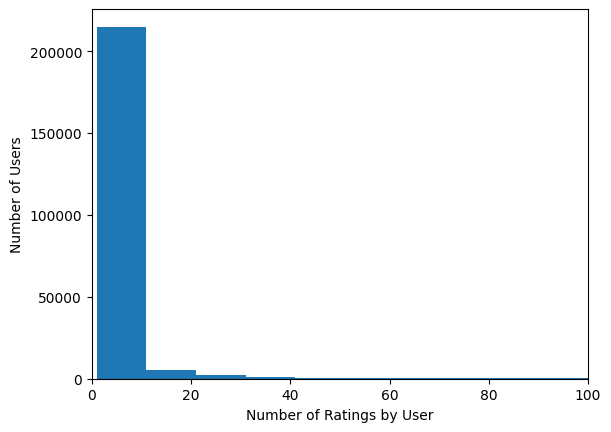

In [14]:
# histogram of number of number of ratings by user;
# 95% of users have rated less than 10 times
plt.hist(num_ratings_by_user, bins=np.arange(1,2000,10));
plt.xlim([0,100])

plt.xlabel('Number of Ratings by User')
plt.ylabel('Number of Users')

Text(0, 0.5, 'Number of Users')

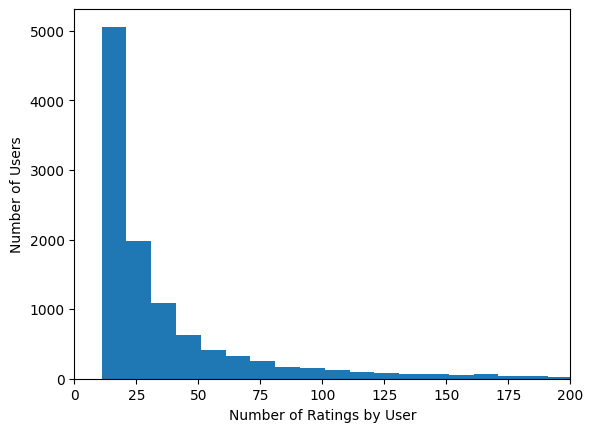

In [18]:
# histogram of number of number of ratings by user but dropping first bin
# 5% of users have rated more than 10 times
plt.hist(num_ratings_by_user[num_ratings_by_user.review>n], bins=np.arange(1,2000,10));
plt.xlim([0,200])

plt.xlabel('Number of Ratings by User')
plt.ylabel('Number of Users')

## To-Do:
- ~~Find database connecting ingredients to cost (Andy)~~
    - Price estimates found here (https://www.ers.usda.gov/data-products/purchase-to-plate)
- ~~Make sense of nutrition list and split into different columns (Andy)~~
- ~~Make sense of techniques (Andy)~~
    - technique encoding in PP_recipes.csv seems too large
    - Create technique encoding by referencing known list of cooking techniques
- For ingredients need to reduce dimensionality
    - Use a LLM to create mapping
    - Want original ingredient, what LLM thinks ingredient should be mapped to, and certainty of mapping
        - For uncertain mappings, do manually
- ~~See if can find url to recipe and link to recipe page~~
    - Do this by searching the name of the recipe on food.com/search/ then grabbing first returned item
    - Was just recipe.com/recipe/name+id
- UI things
- Learn Django

In [6]:
import re

### Grabbing url for each recipe

In [4]:
recipes.head(3)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


In [41]:
def get_url(df):
    urls = []
    for my_name, my_id in zip(df['name'], df['id']):
        try:
            urls.append('https://www.food.com/recipe/' + re.sub(' +', '-', my_name) + '-' + str(my_id))
        except TypeError:
            urls.append('TypeError')
    df['url'] = urls
    return df

In [37]:
urls = []
for my_name, my_id in zip(recipes['name'], recipes['id']):
    try:
        urls.append('https://www.food.com/recipe/' + re.sub(' +', '-', my_name) + '-' + str(my_id))
    except TypeError:
        urls.append('TypeError')
recipes['url'] = urls

### Finding cost for ingredients

Referencing https://www.ers.usda.gov/data-products/purchase-to-plate
- Too many products in this dataset
- Can reduce by truncating description or by merging by food_code
    - truncating description allows us to connect with food.com ingredients list
    - merging by food_code may make more sense for averaging cost

In [45]:
prices = pd.read_csv('../data/raw/pp_national_average_prices_csv/pp_national_average_prices_csv.csv',encoding='cp1252')

In [53]:
unique_food_codes = prices.food_code.unique()

In [83]:
len(unique_food_codes)

6412

In [59]:
prices.head(3)

,year,food_code,mod_code,food_description,method,method_description,nhanes,price_100gm
0,2011/2012,11100000.0,0.0,"Milk, NFS",4,FNDDS recipe with modified SR codes,NaN,0.091897
1,2011/2012,11111000.0,0.0,"Milk, cow's, fluid, whole (Includes 3.5% or 3....",1,Links to FNDDS,NaN,0.094505
2,2011/2012,11112110.0,0.0,"Milk, cow's, fluid, 2% fat (Includes Hi-Protei...",1,Links to FNDDS,NaN,0.088018


In [89]:
prices['shortened_description'] = prices['food_description'].apply(lambda x: ''.join(x.split(',')[:2]).lower())

In [90]:
avg_price = prices[['shortened_description', 'price_100gm']].groupby('shortened_description').mean()

In [91]:
avg_price.rename(columns={'price_100gm':'avg_price_100gm'}, inplace=True)

In [92]:
merged_prices = pd.merge(prices, avg_price, on='shortened_description', how='left')

In [96]:
merged_prices.head(5)

,year,food_code,mod_code,food_description,method,method_description,nhanes,price_100gm,shortened_description,avg_price_100gm
0,2011/2012,11100000.0,0.0,"Milk, NFS",4,FNDDS recipe with modified SR codes,NaN,0.091897,milk nfs,0.099099
1,2011/2012,11111000.0,0.0,"Milk, cow's, fluid, whole (Includes 3.5% or 3....",1,Links to FNDDS,NaN,0.094505,milk cow's,0.140485
2,2011/2012,11112110.0,0.0,"Milk, cow's, fluid, 2% fat (Includes Hi-Protei...",1,Links to FNDDS,NaN,0.088018,milk cow's,0.140485
3,2011/2012,11112210.0,0.0,"Milk, cow's, fluid, 1% fat (Includes Lucerne P...",1,Links to FNDDS,NaN,0.089206,milk cow's,0.140485
4,2011/2012,11113000.0,0.0,"Milk, cow's, fluid, skim or nonfat, 0.5% or le...",1,Links to FNDDS,NaN,0.088424,milk cow's,0.140485


### Making sense of nutrition list and splitting

From Kaggle, nutrition is in array with elements indicating the (calories (#), total fat (PDV), sugar (PDV) , sodium (PDV) , protein (PDV) , saturated fat)

In [97]:
recipes.head(3)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,url
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,https://www.food.com/recipe/arriba-baked-winte...
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6,https://www.food.com/recipe/a-bit-different-br...
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13,https://www.food.com/recipe/all-in-the-kitchen...


In [106]:
split_col_names = ['Calories (#)', 'Total Fat (PDV)', 'Sugar (PDV)', 'Sodium (PDV)', 'Protein (PDV)', 'Saturated Fat (PDV)', 'Total Carbohydrates (PDV)']
split_cols = recipes['nutrition'].str.replace(r"[\[\]'\"]", '', regex=True)
split_cols = split_cols.str.split(', ', expand=True)
recipes[split_col_names] = split_cols
recipes[split_col_names] = recipes[split_col_names].astype('float32')

In [110]:
recipes[split_col_names] = recipes[split_col_names].round(2)

In [114]:
pd.set_option('display.precision', 2)
recipes.head(3)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients,url,Calories (#),Total Fat (PDV),Sugar (PDV),Sodium (PDV),Protein (PDV),Saturated Fat (PDV),Total Carbohydrates (PDV)
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7,https://www.food.com/recipe/arriba-baked-winte...,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6,https://www.food.com/recipe/a-bit-different-br...,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13,https://www.food.com/recipe/all-in-the-kitchen...,269.8,22.0,32.0,48.0,39.0,27.0,5.0


### Making sense of techniques

#### grabbing comprehensive list of techniques from wikipedia page

https://en.wikipedia.org/wiki/List_of_cooking_techniques

In [117]:
import requests
import re
from bs4 import BeautifulSoup

In [118]:
def get_techniques_wiki():
    url = 'https://en.wikipedia.org/wiki/List_of_cooking_techniques'
    headers = {'User-Agent': 'av888@drexel.edu'}
    
    response = requests.get(url, headers=headers)
    
    soup = BeautifulSoup(response.text, 'html.parser')
    
    return response, soup

In [119]:
response, soup = get_techniques_wiki()

In [125]:
tech_groups = soup.find_all('dl', class_='glossary')

In [139]:
techniques = []
for group in tech_groups:
    # grabs name of technique
    tech_names = group.find_all('dt')
    # grabs description of technique
    tech_descriptions = group.find_all('dd')
    for name, desc in zip(tech_names, tech_descriptions):
        techniques.append([name.text, desc.text])

In [142]:
all_techniques = pd.DataFrame(techniques, columns=['name', 'description'])

In [144]:
all_techniques.to_csv('../data/raw/cooking_techniques_wiki.csv', index=False)

In [162]:
cleaned_techniques = all_techniques.copy()
# remove citation
cleaned_techniques['description'] = cleaned_techniques['description'].str.replace(r'\[.*\]', '', regex=True)

In [163]:
cleaned_techniques.to_csv('../data/interim/cooking_techniques_wiki.csv', index=False)

In [161]:
# manually cleaning from here
# removing items and adding/editing descriptions
# will add items if think of any

## Data Exploration
Question: What preprocessing do we need to do to the recipes dataset?
- Cuisine tag is contained in tags column -> will want to extract and separate into its own column
- Want to stem ingredients for simplified filtering
    - Then maybe want to encode into integers for easy comparison between recipes; could also use a word embedding

In [141]:
import re

In [3]:
recipes.head(3)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


In [84]:
recipes.info()

<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   name            231636 non-null  str  
 1   id              231637 non-null  int64
 2   minutes         231637 non-null  int64
 3   contributor_id  231637 non-null  int64
 4   submitted       231637 non-null  str  
 5   tags            231637 non-null  str  
 6   nutrition       231637 non-null  str  
 7   n_steps         231637 non-null  int64
 8   steps           231637 non-null  str  
 9   description     226658 non-null  str  
 10  ingredients     231637 non-null  str  
 11  n_ingredients   231637 non-null  int64
dtypes: int64(5), str(7)
memory usage: 293.5 MB


In [144]:
def convert_str_to_list(df: pd.DataFrame, cols: str):
    '''
    Converts column of string which are list-like to a list of strings
    Meant to used for tags, nutrition, steps, and ingredients
    '''
    for col in cols:
        if type(df[col][0]) == list:
            print('already as list')
            continue
        my_list_lists = []
        for ind, val in enumerate(df[col]):
            new_s = re.sub(r"[\[\]'\"]", '', val)
            new_s = re.sub(r',\s+', ',', new_s)
            my_list = new_s.split(',')
            if col == 'nutrition':
                my_list = [float(x) for x in my_list]
            my_list_lists.append(my_list)
        df[col] = my_list_lists
    return df        

In [146]:
recipes = convert_str_to_list(recipes, ['tags', 'nutrition', 'steps', 'ingredients'])

In [147]:
recipes.head(3)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"[60-minutes-or-less, time-to-make, course, mai...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"[make a choice and proceed with recipe, depend...",autumn is my favorite time of year to cook! th...,"[winter squash, mexican seasoning, mixed spice...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"[30-minutes-or-less, time-to-make, course, mai...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"[preheat oven to 425 degrees f, press dough in...",this recipe calls for the crust to be prebaked...,"[prepared pizza crust, sausage patty, eggs, mi...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"[time-to-make, course, preparation, main-dish,...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"[brown ground beef in large pot, add chopped o...",this modified version of 'mom's' chili was a h...,"[ground beef, yellow onions, diced tomatoes, t...",13


In [148]:
recipes.info()

<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name            231636 non-null  str   
 1   id              231637 non-null  int64 
 2   minutes         231637 non-null  int64 
 3   contributor_id  231637 non-null  int64 
 4   submitted       231637 non-null  str   
 5   tags            231637 non-null  object
 6   nutrition       231637 non-null  object
 7   n_steps         231637 non-null  int64 
 8   steps           231637 non-null  object
 9   description     226658 non-null  str   
 10  ingredients     231637 non-null  object
 11  n_ingredients   231637 non-null  int64 
dtypes: int64(5), object(4), str(3)
memory usage: 72.9+ MB


In [149]:
all_ingredients = []
for i in recipes.ingredients:
    all_ingredients.extend(i)
all_ingredients = list(set(all_ingredients))

In [150]:
len(all_ingredients)

14902

In [161]:
all_ingredients

['goji berries',
 'large-curd cottage cheese',
 'cream of chicken and mushroom soup',
 'crunch bars',
 'chicken and broccoli flavor rice-a-roni',
 'pepper leaves',
 'meatloaf mix',
 'pillsbury plus devils food cake mix',
 'red pasta sauce',
 'pork gravy',
 'orange',
 'turkey london broil',
 'glace ginger',
 'dried tart cherry',
 'unbaked pastry shell',
 'broccoli and cheese flavored rice mix',
 'roasted walnut',
 'kalamata olive',
 'soy bacon bits',
 'eidam cheese',
 'quick-cooking polenta',
 'black fungus mushrooms',
 'apricot filling',
 'dried soybeans',
 'infant cereal',
 'sweet white onion',
 'parmesan-romano cheese mix',
 'butternut squash seeds',
 'hot and spicy shake-and-bake',
 'root beer',
 'orange-pineapple flavored gelatin',
 'sugar-free cool whip',
 'canned cannellini',
 'garlic rice and vermicelli mix',
 'ginger-garlic paste',
 'ranch style black-eyed peas',
 'sheep milk',
 'mini jelly rolls',
 'wine biscuits',
 'toothpicks',
 'cooked whole wheat penne',
 'peppermint candy

In [151]:
all_tags = []
for x in recipes['tags']:
    all_tags.extend(x)
all_tags = list(set(all_tags))

In [152]:
len(all_tags)

552

In [153]:
all_tags

['',
 'honduran',
 'ham',
 'egg-free',
 'bar-cookies',
 'fudge',
 'vietnamese',
 'southern-united-states',
 'weeknight',
 'whitefish',
 'trout',
 'lasagna',
 'quiche',
 'rosh-hashana',
 '3-steps-or-less',
 'manicotti',
 'peanut-butter',
 'avocado',
 'non-alcoholic',
 'picnic',
 'desserts-fruit',
 'rolled-cookies',
 'lasagne',
 'tuna',
 'sudanese',
 'reynolds-wrap',
 'shrimp',
 'ground-beef',
 'independence-day',
 'toddler-friendly',
 'brown-bag',
 'blueberries',
 'simply-potatoes',
 'coconut',
 'georgian',
 'pacific-northwest',
 'berries',
 'vegan',
 'orange-roughy',
 'cod',
 'bread-pudding',
 'crawfish',
 'north-american',
 'small-appliance',
 'beijing',
 'holiday-event',
 'savory',
 'steam',
 'veal',
 'salsas',
 'northeastern-united-states',
 'wings',
 'crusts-pastry-dough-2',
 'less_thansql:name_topics_of_recipegreater_than',
 'casseroles',
 'icelandic',
 'tempeh',
 'chicken-thighs-legs',
 'eggplant',
 'condiments-etc',
 'hanukkah',
 'peppers',
 'served-hot-new-years',
 'canadian',


In [160]:
for x in recipes.tags:
    if len(x) == 0:
        print(x)

In [162]:
all_tags

['',
 'honduran',
 'ham',
 'egg-free',
 'bar-cookies',
 'fudge',
 'vietnamese',
 'southern-united-states',
 'weeknight',
 'whitefish',
 'trout',
 'lasagna',
 'quiche',
 'rosh-hashana',
 '3-steps-or-less',
 'manicotti',
 'peanut-butter',
 'avocado',
 'non-alcoholic',
 'picnic',
 'desserts-fruit',
 'rolled-cookies',
 'lasagne',
 'tuna',
 'sudanese',
 'reynolds-wrap',
 'shrimp',
 'ground-beef',
 'independence-day',
 'toddler-friendly',
 'brown-bag',
 'blueberries',
 'simply-potatoes',
 'coconut',
 'georgian',
 'pacific-northwest',
 'berries',
 'vegan',
 'orange-roughy',
 'cod',
 'bread-pudding',
 'crawfish',
 'north-american',
 'small-appliance',
 'beijing',
 'holiday-event',
 'savory',
 'steam',
 'veal',
 'salsas',
 'northeastern-united-states',
 'wings',
 'crusts-pastry-dough-2',
 'less_thansql:name_topics_of_recipegreater_than',
 'casseroles',
 'icelandic',
 'tempeh',
 'chicken-thighs-legs',
 'eggplant',
 'condiments-etc',
 'hanukkah',
 'peppers',
 'served-hot-new-years',
 'canadian',


In [163]:
pp_recipes = pd.read_csv('../data/raw/PP_recipes.csv')

In [164]:
pp_recipes.head(3)

,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696..."


In [167]:
len(pp_recipes.techniques[0])

174